# Laborator 5: Imagini

In [26]:
%matplotlib inline
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
from skimage.metrics import structural_similarity as ssim
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Optional AVIF support
# pip install pillow-avif-plugin
try:
    import pillow_avif  # noqa: F401
    AVIF_AVAILABLE = True
except ImportError:
    AVIF_AVAILABLE = False
    print("Warning: pillow-avif-plugin not found — AVIF will be skipped.")


IMAGE_NAME = "dice"
IMG = f"img/{IMAGE_NAME}.png"
os.makedirs("output", exist_ok=True)

## 1. Save image as a jpeg file and see its size

Quality 10: 12014 bytes
Quality 20: 15029 bytes
Quality 30: 17490 bytes
Quality 40: 19610 bytes
Quality 50: 21723 bytes
Quality 60: 23876 bytes
Quality 70: 27268 bytes
Quality 80: 32948 bytes
Quality 90: 45992 bytes
Quality 100: 127464 bytes


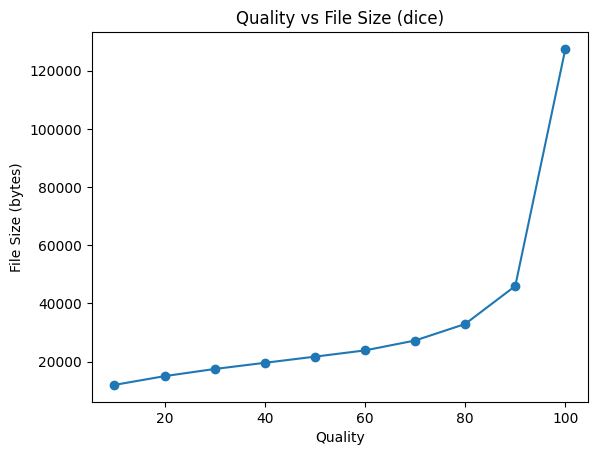

Saved output/quality_vs_size_dice.png


In [27]:
qualities = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

img = Image.open(IMG)

# Convertim imaginea in RGB deoarece formatul original este RGBA (cu canal alpha)
# si formatul JPEG nu suporta canal alpha
img_rgb = img.convert("RGB")

for q in qualities:
    img_rgb.save(f"output/{IMAGE_NAME}_q{q}.jpg", "JPEG", quality=q)
    print(f"Quality {q}: {os.path.getsize(f'output/{IMAGE_NAME}_q{q}.jpg')} bytes")

sizes_jpeg = [os.path.getsize(f"output/{IMAGE_NAME}_q{q}.jpg") for q in qualities] # aici genereaza vectorul de dimensiuni


# Acuma plotam rezultatele
plt.figure()
plt.plot(qualities, sizes_jpeg, marker="o")
plt.xlabel("Quality")
plt.ylabel("File Size (bytes)")
plt.title(f"Quality vs File Size ({IMAGE_NAME})")
plt.savefig(f"output/quality_vs_size_{IMAGE_NAME}.png")
plt.show()
print(f"Saved output/quality_vs_size_{IMAGE_NAME}.png")

## Acuma pentru acceasi imagine, folosim webp si avif

Quality 10: 38928 bytes
Quality 20: 39708 bytes
Quality 30: 40680 bytes
Quality 40: 41900 bytes
Quality 50: 43026 bytes
Quality 60: 44006 bytes
Quality 70: 45064 bytes
Quality 80: 48146 bytes
Quality 90: 56440 bytes
Quality 100: 85944 bytes


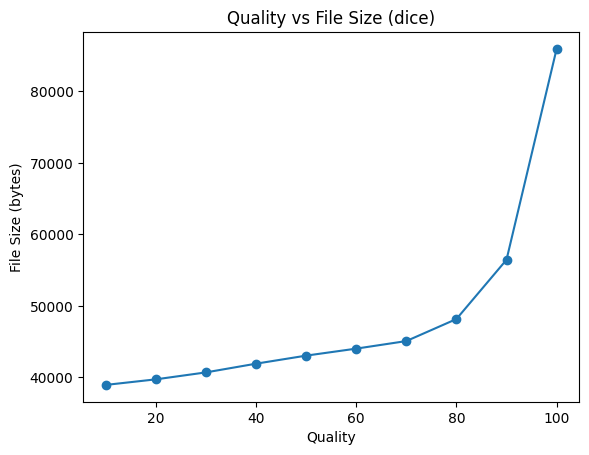

Saved output/quality_vs_size_dice.png


In [28]:
# WebP
for q in qualities:
    path = f"output/{IMAGE_NAME}_q{q}.webp"
    img.save(path, "WEBP", quality=q)
    print(f"Quality {q}: {os.path.getsize(path)} bytes")

sizes_webp = [os.path.getsize(f"output/{IMAGE_NAME}_q{q}.webp") for q in qualities] # aici genereaza vectorul de dimensiuni

# Plotam rezultatele
plt.figure()
plt.plot(qualities, sizes_webp, marker="o")
plt.xlabel("Quality")
plt.ylabel("File Size (bytes)")
plt.title(f"Quality vs File Size ({IMAGE_NAME})")
plt.savefig(f"output/quality_vs_size_{IMAGE_NAME}.png")
plt.show()
print(f"Saved output/quality_vs_size_{IMAGE_NAME}.png")

Quality 10: 4057 bytes
Quality 20: 5349 bytes
Quality 30: 6826 bytes
Quality 40: 9126 bytes
Quality 50: 12004 bytes
Quality 60: 17182 bytes
Quality 70: 22073 bytes
Quality 80: 28254 bytes
Quality 90: 45360 bytes
Quality 100: 122736 bytes


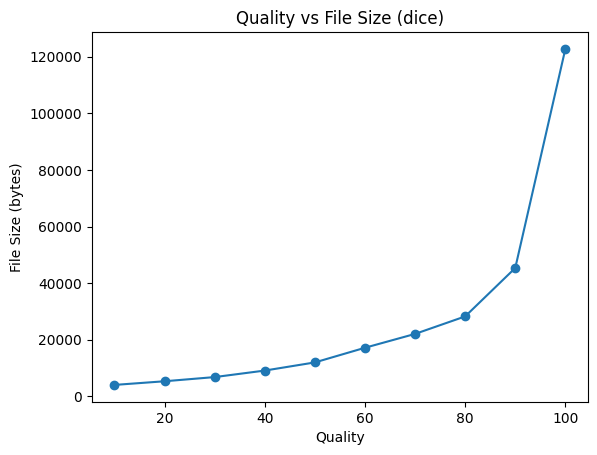

Saved output/quality_vs_size_dice.png


In [29]:
# Pe asta probabil o sa il dau ca exercitiu
# AVIF
for q in qualities:
    path = f"output/{IMAGE_NAME}_q{q}.avif"
    img.save(path, "AVIF", quality=q)
    print(f"Quality {q}: {os.path.getsize(path)} bytes")

sizes_avif = [os.path.getsize(f"output/{IMAGE_NAME}_q{q}.avif") for q in qualities]

plt.figure()
plt.plot(qualities, sizes_avif, marker="o")
plt.xlabel("Quality")
plt.ylabel("File Size (bytes)")
plt.title(f"Quality vs File Size ({IMAGE_NAME})")
plt.savefig(f"output/quality_vs_size_{IMAGE_NAME}.png")
plt.show()
print(f"Saved output/quality_vs_size_{IMAGE_NAME}.png")

## 2. Comparație vizuală: original vs JPEG

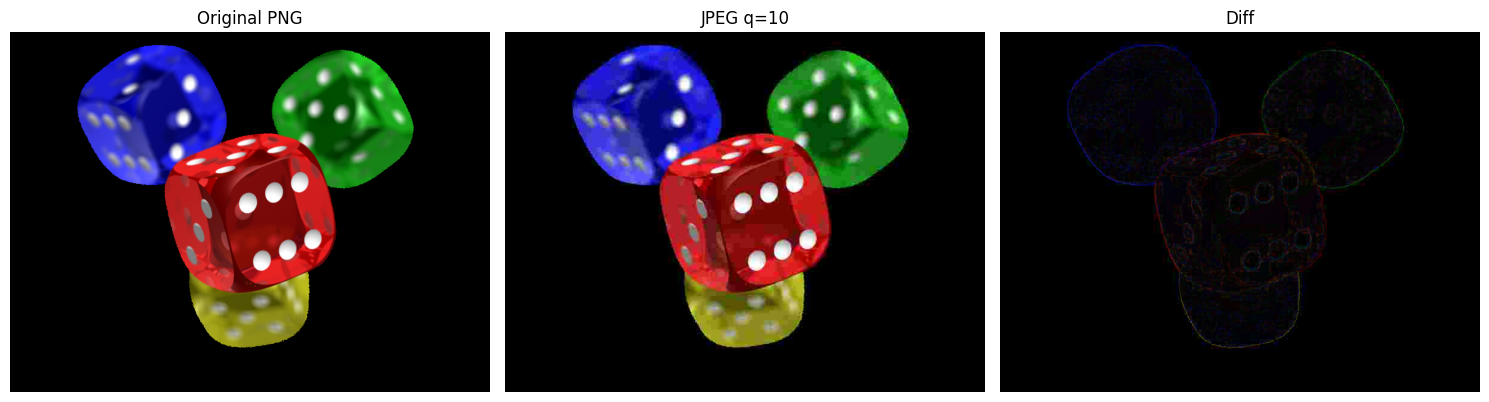

In [30]:
# Putem sa facem si pt jpeg si pt avif
original   = np.array(Image.open(IMG).convert("RGB"))
compressed = np.array(Image.open(f"output/{IMAGE_NAME}_q10.jpg").convert("RGB"))
diff = cv2.absdiff(original, compressed)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original);   axes[0].set_title("Original PNG"); axes[0].axis("off")
axes[1].imshow(compressed); axes[1].set_title(f"JPEG q=10");    axes[1].axis("off")
axes[2].imshow(diff);       axes[2].set_title("Diff");         axes[2].axis("off")
plt.tight_layout()
plt.show()

# 2.1 Comparație vizuală: original vs WebP

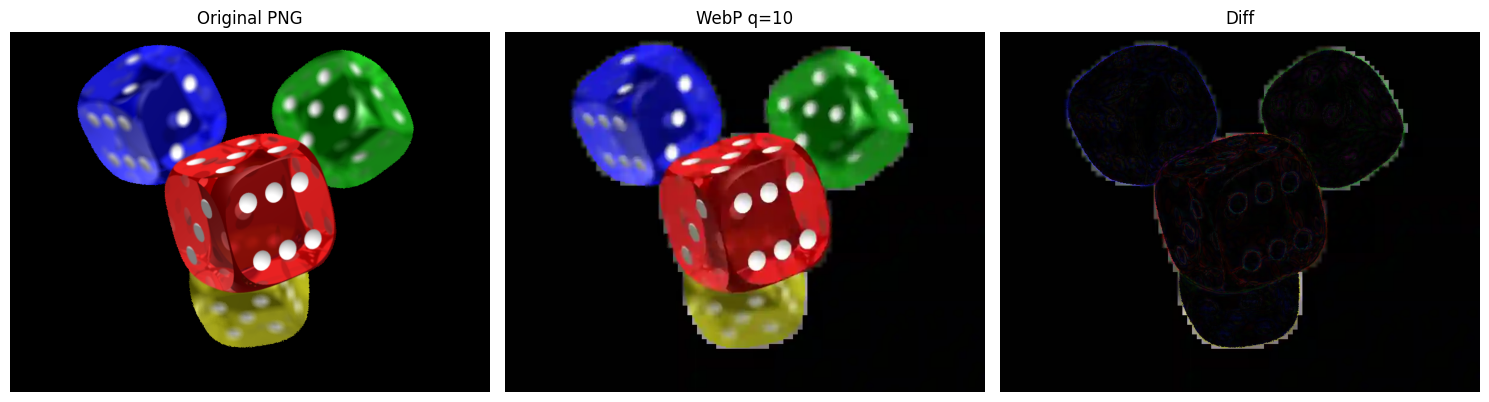

In [31]:
compressed = np.array(Image.open(f"output/{IMAGE_NAME}_q10.webp").convert("RGB"))
diff = cv2.absdiff(original, compressed)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original);   axes[0].set_title("Original PNG");  axes[0].axis("off")
axes[1].imshow(compressed); axes[1].set_title("WebP q=10");     axes[1].axis("off")
axes[2].imshow(diff);       axes[2].set_title("Diff");          axes[2].axis("off")
plt.tight_layout()
plt.show()

# 2.2 Comparație vizuală: original vs AVIF

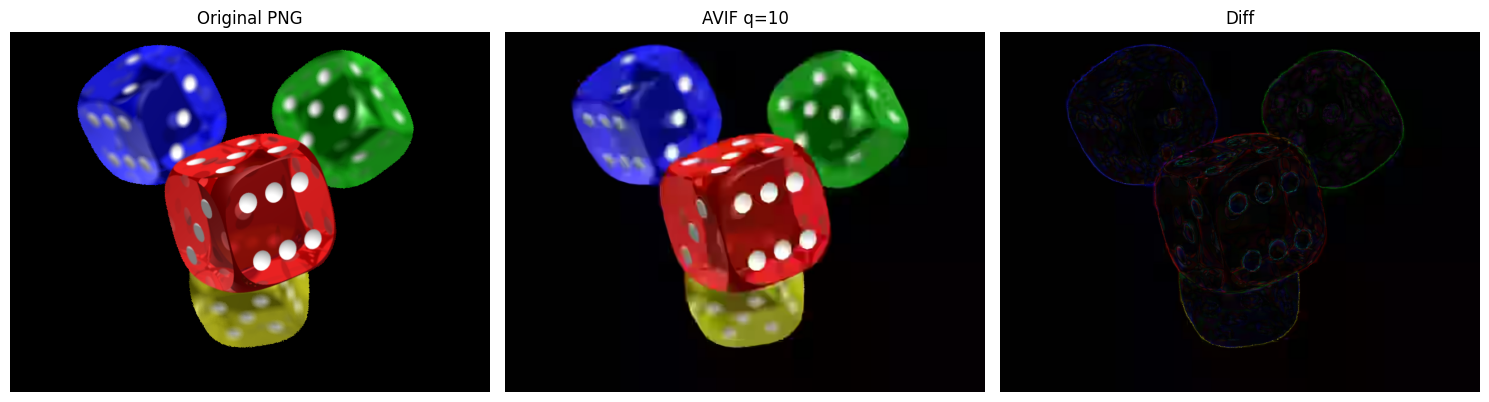

In [32]:
compressed = np.array(Image.open(f"output/{IMAGE_NAME}_q10.avif").convert("RGB"))
diff = cv2.absdiff(original, compressed)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original);   axes[0].set_title("Original PNG");  axes[0].axis("off")
axes[1].imshow(compressed); axes[1].set_title("AVIF q=10");     axes[1].axis("off")
axes[2].imshow(diff);       axes[2].set_title("Diff");          axes[2].axis("off")
plt.tight_layout()
plt.show()

## 3. Comparam algoritmi de compresie pe o imagine "cu zgomot"

In [ ]:
noise = np.random.randint(0, 255, (10000, 1000, 3), dtype=np.uint8)
noise_img = Image.fromarray(noise)

# format: lista de (nume, format PIL, extra kwargs - argumente ce vor fi pasate la noise_img.save)
formats = [
    ("png",            "PNG",  {}),
    ("webp",           "WEBP", {}),
    ("webp_lossless",  "WEBP", {"lossless": True}),
    ("jpg",            "JPEG", {}),
    ("tif",            "TIFF", {}),
    ("tif_lzw",        "TIFF", {"compression": "tiff_lzw"}),
    ("tif_deflate",    "TIFF", {"compression": "tiff_deflate"}),
    ("bmp",            "BMP",  {}),
]
if AVIF_AVAILABLE:
    formats.append(("avif", "AVIF", {}))

for name, fmt, kwargs in formats:
    path = f"output/noise_{name}.{name.split('_')[0]}"
    noise_img.save(path, format=fmt, **kwargs) # adica aici!!
    size = os.path.getsize(path)
    print(f"{name:<14} size: {size / 1024:.2f} KB")

png            size: 29325.34 KB
webp           size: 6605.83 KB
webp_lossless  size: 29282.41 KB
jpg            size: 5868.11 KB
tif            size: 29297.01 KB
tif_lzw        size: 40118.15 KB
tif_deflate    size: 29312.84 KB
bmp            size: 29296.93 KB
avif           size: 7692.71 KB


## 4. Image quality metrics: PSNR & SSIM

In [ ]:
# https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio 
# TLDR: cat de mult difera cele 2 imagini, cu cat e mai mare cu atat mai bine
def compute_psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float("inf")
    return 10 * np.log10((255.0 ** 2) / mse)

# https://en.wikipedia.org/wiki/Structural_similarity_index_measure 
# TLDR: cat de similare sunt cele 2 imagini, cu cat e mai aproape de 1 cu atat mai bine (cuprins intre 0 si 1)
# aici o sa masuram luminozitatea, contrastul, asa ca avem nevoie de formatul YCrCb sau YUV
# https://en.wikipedia.org/wiki/YUV
def compute_ssim(img1, img2):
    y1 = cv2.cvtColor(img1, cv2.COLOR_RGB2YCrCb)[:, :, 0]
    y2 = cv2.cvtColor(img2, cv2.COLOR_RGB2YCrCb)[:, :, 0]
    score, _ = ssim(y1, y2, full=True)
    return score

In [ ]:
# WebP
results_webp = []
for q in qualities:
    comp = np.array(Image.open(f"output/{IMAGE_NAME}_q{q}.webp").convert("RGB"))
    results_webp.append((q, compute_psnr(original, comp), compute_ssim(original, comp)))
    print(f"Quality {q:3d} | PSNR: {results_webp[-1][1]:.2f} dB | SSIM: {results_webp[-1][2]:.4f}")

qs, psnrs, ssims_vals = zip(*results_webp)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(qs, psnrs,      marker="o", color="steelblue");  ax1.set_xlabel("Quality"); ax1.set_ylabel("PSNR (dB)"); ax1.set_title("WebP — Quality vs PSNR")
ax2.plot(qs, ssims_vals, marker="o", color="darkorange"); ax2.set_xlabel("Quality"); ax2.set_ylabel("SSIM");      ax2.set_title("WebP — Quality vs SSIM")
plt.tight_layout()
plt.savefig("output/quality_metrics.png")
plt.show()
print("Saved output/quality_metrics.png")

In [ ]:
# AVIF
results_avif = []
for q in qualities:
    comp = np.array(Image.open(f"output/{IMAGE_NAME}_q{q}.avif").convert("RGB"))
    results_avif.append((q, compute_psnr(original, comp), compute_ssim(original, comp)))
    print(f"Quality {q:3d} | PSNR: {results_avif[-1][1]:.2f} dB | SSIM: {results_avif[-1][2]:.4f}")

qs, psnrs, ssims_vals = zip(*results_avif)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(qs, psnrs,      marker="o", color="steelblue");  ax1.set_xlabel("Quality"); ax1.set_ylabel("PSNR (dB)"); ax1.set_title("AVIF — Quality vs PSNR")
ax2.plot(qs, ssims_vals, marker="o", color="darkorange"); ax2.set_xlabel("Quality"); ax2.set_ylabel("SSIM");      ax2.set_title("AVIF — Quality vs SSIM")
plt.tight_layout()
plt.savefig(f"output/quality_metrics_{IMAGE_NAME}_avif.png")
plt.show()
print(f"Saved output/quality_metrics_{IMAGE_NAME}_avif.png")

## 5. Fourier Transform (3-D surface): original PNG vs WebP-compressed

In [ ]:
def fft_magnitude(img_array):
    """Return the log-scaled 2-D FFT magnitude spectrum of a grayscale image."""
    gray   = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    fshift = np.fft.fftshift(np.fft.fft2(gray))
    return 20 * np.log10(np.abs(fshift) + 1)   # +1 avoids log(0)

def downsample(arr, target=200):
    """Downsample a 2-D array to at most target x target for fast 3-D rendering."""
    sy = max(1, arr.shape[0] // target)
    sx = max(1, arr.shape[1] // target)
    return arr[::sy, ::sx]

In [ ]:
# Change fft_webp_quality to compare a different compression level
fft_webp_quality = 30
fft_webp_path    = f"output/{IMAGE_NAME}_q{fft_webp_quality}.webp"

original_rgb = np.array(Image.open(IMG).convert("RGB"))
webp_rgb     = np.array(Image.open(fft_webp_path).convert("RGB"))

mag_orig = downsample(fft_magnitude(original_rgb))
mag_webp = downsample(fft_magnitude(webp_rgb))

vmin = min(mag_orig.min(), mag_webp.min())
vmax = max(mag_orig.max(), mag_webp.max())

fig = plt.figure(figsize=(14, 6))

for idx, (mag, label) in enumerate(
    [(mag_orig, "Original PNG"), (mag_webp, f"WebP q={fft_webp_quality}")]
):
    rows, cols = mag.shape
    # Normalized frequency axes: -0.5 … +0.5 cycles/pixel (DC centred by fftshift)
    fx = np.fft.fftshift(np.fft.fftfreq(cols))
    fy = np.fft.fftshift(np.fft.fftfreq(rows))
    X, Y = np.meshgrid(fx, fy)

    ax = fig.add_subplot(1, 2, idx + 1, projection="3d")
    surf = ax.plot_surface(X, Y, mag, cmap="inferno",
                           vmin=vmin, vmax=vmax,
                           linewidth=0, antialiased=False)
    ax.set_title(f"FFT Magnitude — {label}")
    ax.set_xlabel("Frequency X (cycles/px)")
    ax.set_ylabel("Frequency Y (cycles/px)")
    ax.set_zlabel("Magnitude (dB)")
    ax.set_zlim(vmin, vmax)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(surf, cax=cbar_ax, label="Magnitude (dB)")
plt.suptitle("2-D Fourier Transform — 3-D Surface Comparison", fontsize=14)
plt.subplots_adjust(right=0.90)
plt.savefig(f"output/fft_comparison_{IMAGE_NAME}.png", bbox_inches="tight")
plt.show()
print(f"Saved output/fft_comparison_{IMAGE_NAME}.png")